In [73]:
import numpy as np, matplotlib.pyplot as plt, math, scipy as sp

In [74]:
#1a
p = 0
for x in range(100):
    p += sp.stats.poisson.pmf(x, 2) * sp.stats.poisson.cdf(x - 1, 1.5)
print(p)

0.4935624168931794


In [75]:
#1b
y = []
for t in range(91):
    temp = 0
    for x in range(100):
        temp += sp.stats.poisson.pmf(x, (2/90) * (90 - t)) * sp.stats.poisson.pmf(x, (1.5/90) * (90 - t))
    y.append(temp)

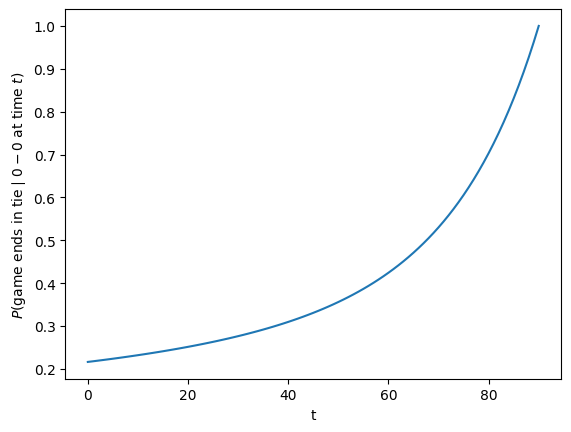

In [76]:
plt.plot(np.arange(91), y)
plt.xlabel("t")
plt.ylabel(r"$P(\text{game ends in tie}\mid 0-0 \text{ at time }t)$")
plt.savefig('figures/1b_1.png', dpi = 300, bbox_inches = 'tight')

In [77]:
#1c
y = []
for t in range(91):
    temp = 0
    if t < 60:
        for x in range(100):
            temp += sp.stats.poisson.pmf(x, (2/90) * (90 - t)) * sp.stats.poisson.pmf(x, (1.5/90) * (90 - t))
    else:
        for x in range(100):
            temp += sp.stats.poisson.pmf(x + 1, (2/90) * (90 - t)) * sp.stats.poisson.pmf(x, (1.5/90) * (90 - t))
    y.append(temp)

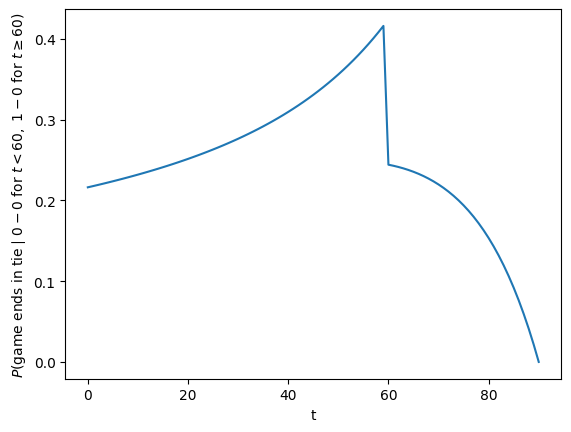

In [78]:
plt.plot(np.arange(91), y)
plt.xlabel("t")
plt.ylabel(r"$P(\text{game ends in tie}\mid 0-0 \text{ for }t<60,\ 1-0 \text{ for }t\geq60)$")
plt.savefig('figures/1c_1.png', dpi = 300, bbox_inches = 'tight')

In [79]:
#2c
def simulate_poisson_process(rate, T):
    """Simulate event times for a Poisson process using exponential interarrivals."""
    times = []
    t = 0
    while True:
        t += np.random.exponential(1 / rate)
        if t > T:
            break
        times.append(t)
    return np.array(times)

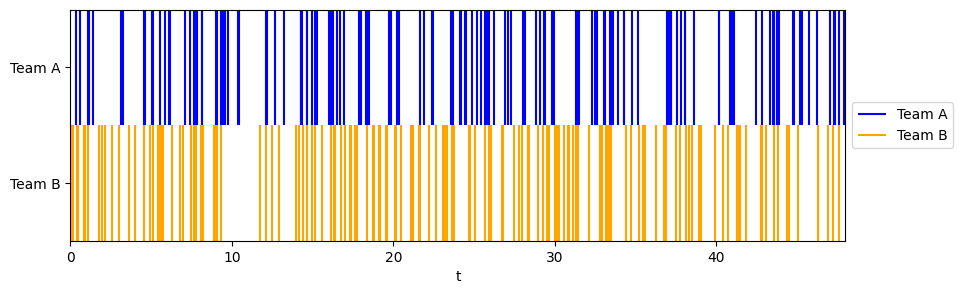

In [80]:
#2c
T = 48
lam = 3
times_A = simulate_poisson_process(lam, T)
times_B = simulate_poisson_process(lam, T)
plt.figure(figsize=(10, 3))
plt.vlines(times_A, ymin = 0.5, ymax = 1.0, label = 'Team A', color = 'blue')
plt.vlines(times_B, ymin = 0.0, ymax = 0.5, label = 'Team B', color = 'orange')
plt.ylim(0, 1)
plt.xlim(0, T)
plt.xlabel(r"t")
plt.yticks([0.25, 0.75], ["Team B", "Team A"])
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.savefig('figures/2c_1.png', dpi = 300, bbox_inches = 'tight')

In [81]:
#2d
def simulate_combined_process(rate, T):
    times = []
    t = 0
    while True:
        t += np.random.exponential(1 / rate)
        if t > T:
            break
        times.append(t)
    return np.array(times)

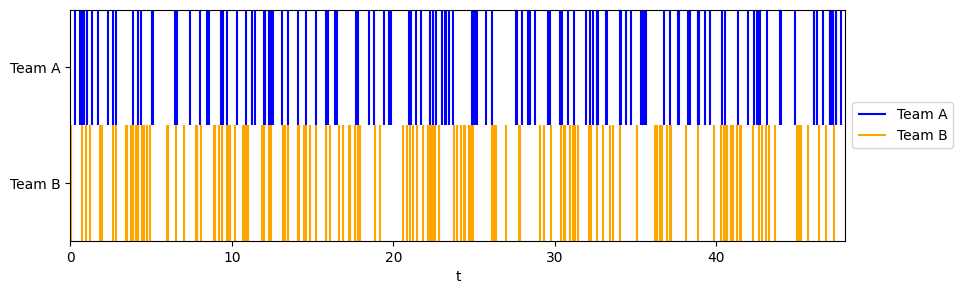

In [82]:
T = 48
lam = 3
times = simulate_combined_process(2 * lam, T)
assignments = np.random.rand(len(times)) < 0.5
times_A = times[assignments]
times_B = times[~assignments]
plt.figure(figsize=(10, 3))
plt.vlines(times_A, ymin = 0.5, ymax = 1.0, label = 'Team A', color = 'blue')
plt.vlines(times_B, ymin = 0.0, ymax = 0.5, label = 'Team B', color = 'orange')
plt.ylim(0, 1)
plt.xlim(0, T)
plt.xlabel(r"t")
plt.yticks([0.25, 0.75], ["Team B", "Team A"])
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.savefig('figures/2d_1.png', dpi = 300, bbox_inches = 'tight')

In [83]:
#2e
T = 48
lam = 3
n_sim = 10 ** 5
N = np.random.poisson(2 * lam * T, size=n_sim)
N_A = np.random.binomial(N, 0.5)
N_B = N - N_A
D = 2 * (N_A - N_B)
E_hat = np.mean(D)
Var_hat = np.var(D)
P_tie_hat = np.mean(D == 0)
E_theory = 0
Var_theory = 8 * lam * T
P_tie_theory = np.exp(-2 * lam * T) * sp.special.i0(2 * lam * T)
print("Estimated E[D(t)]:", E_hat)
print("Theoretical E[D(t)]:", E_theory)
print()
print("Estimated Var[D(t)]:", Var_hat)
print("Theoretical Var[D(t)]:", Var_theory)
print()
print("Estimated P(D(t)=0):", P_tie_hat)
print("Theoretical P(D(t)=0):", P_tie_theory)

Estimated E[D(t)]: 0.22826
Theoretical E[D(t)]: 0

Estimated Var[D(t)]: 1157.3175373723998
Theoretical Var[D(t)]: 1152

Estimated P(D(t)=0): 0.02361
Theoretical P(D(t)=0): 0.023518122396145806


In [84]:
#3a
f = lambda t: t * ((1/2) + (1/1800) * t ** 2) * np.exp(-((1/2) * t + (1/5400) * t ** 3))
sp.integrate.quad(f, 0, np.inf)

(1.9835239394688793, 3.9145177114095395e-09)

In [85]:
#3c
def lam(t):
    return 0.5 * (1 + (t / 30) ** 2)

375


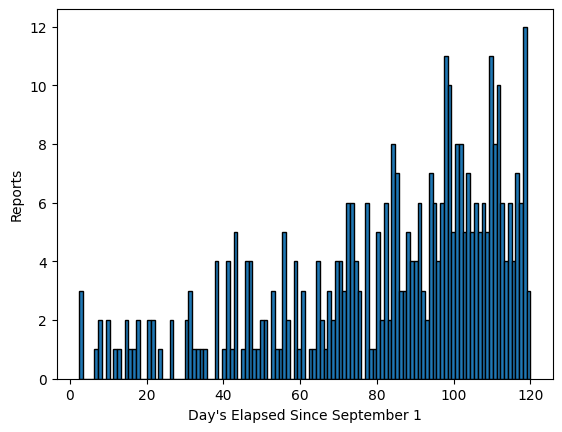

In [86]:
T = 120
lambda_max = lam(120)
t = 0
arrival_times = []
while t < T:
    t += np.random.exponential(1 / lambda_max)
    if t > T:
        break
    if np.random.rand() < lam(t) / lambda_max:
        arrival_times.append(t)
arrival_times = np.array(arrival_times)
plt.hist(arrival_times, bins = 120, ec = 'black')
plt.xlabel("Day's Elapsed Since September 1")
plt.ylabel("Reports")
plt.savefig('figures/3c_1.png', dpi = 300, bbox_inches = 'tight')
simulated_total = len(arrival_times)
print(simulated_total)